# Insider Threat Behavioral Intelligence System
## Milestone 3 - Model Training and Detection

This notebook builds the machine learning pipeline for the Insider Threat Behavioral Intelligence System.

The pipeline includes:

1. Loading CERT Insider Threat Dataset r4.2 activity logs
2. Data preprocessing
3. Daily user-level feature engineering
4. Behavioral labeling
5. Machine learning model training
6. Model evaluation
7. Anomaly detection
8. Model artifact generation

In [7]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

print("Libraries imported successfully.")

Libraries imported successfully.


In [8]:
BASE_PATH = "/kaggle/input/datasets/revsyko/insider-threat-cert-4-2/r4.2"

print(os.listdir(BASE_PATH))

['LDAP', 'logon.csv', 'device.csv', 'psychometric.csv', 'http.csv', 'readme.txt', 'license.txt', 'email.csv', 'file.csv']


In [9]:
logon = pd.read_csv(f"{BASE_PATH}/logon.csv")

print("Logon dataset shape:", logon.shape)
print(logon.head())

Logon dataset shape: (854859, 5)
                         id                 date     user       pc activity
0  {X1D9-S0ES98JV-5357PWMI}  01/02/2010 06:49:00  NGF0157  PC-6056    Logon
1  {G2B3-L6EJ61GT-2222RKSO}  01/02/2010 06:50:00  LRR0148  PC-4275    Logon
2  {U6Q3-U0WE70UA-3770UREL}  01/02/2010 06:53:04  LRR0148  PC-4124    Logon
3  {I0N5-R7NA26TG-6263KNGM}  01/02/2010 07:00:00  IRM0931  PC-7188    Logon
4  {D1S0-N6FH62BT-5398KANK}  01/02/2010 07:00:00  MOH0273  PC-6699    Logon


In [10]:
device = pd.read_csv(f"{BASE_PATH}/device.csv")

print("Device dataset shape:", device.shape)
print(device.head())

Device dataset shape: (405380, 5)
                         id                 date     user       pc    activity
0  {J1S3-L9UU75BQ-7790ATPL}  01/02/2010 07:21:06  MOH0273  PC-6699     Connect
1  {N7B5-Y7BB27SI-2946PUJK}  01/02/2010 07:37:41  MOH0273  PC-6699  Disconnect
2  {U1V9-Z7XT67KV-5649MYHI}  01/02/2010 07:59:11  HPH0075  PC-2417     Connect
3  {H0Z7-E6GB57XZ-1603MOXD}  01/02/2010 07:59:49  IIW0249  PC-0843     Connect
4  {L7P2-G4PX02RX-7999GYOY}  01/02/2010 08:04:26  IIW0249  PC-0843  Disconnect


In [11]:
file_df = pd.read_csv(f"{BASE_PATH}/file.csv")

print("File dataset shape:", file_df.shape)
print(file_df.head())

File dataset shape: (445581, 6)
                         id                 date     user       pc  \
0  {L9G8-J9QE34VM-2834VDPB}  01/02/2010 07:23:14  MOH0273  PC-6699   
1  {H0W6-L4FG38XG-9897XTEN}  01/02/2010 07:26:19  MOH0273  PC-6699   
2  {M3Z0-O2KK89OX-5716MBIM}  01/02/2010 08:12:03  HPH0075  PC-2417   
3  {E1I4-S4QS61TG-3652YHKR}  01/02/2010 08:17:00  HPH0075  PC-2417   
4  {D4R7-E7JL45UX-0067XALT}  01/02/2010 08:24:57  HSB0196  PC-8001   

       filename                                            content  
0  EYPC9Y08.doc  D0-CF-11-E0-A1-B1-1A-E1 during difficulty over...  
1  N3LTSU3O.pdf  25-50-44-46-2D carpenters 25 landed strait dis...  
2  D3D3WC9W.doc  D0-CF-11-E0-A1-B1-1A-E1 union 24 declined impo...  
3  QCSW62YS.doc  D0-CF-11-E0-A1-B1-1A-E1 becoming period begin ...  
4  AU75JV6U.jpg                                              FF-D8  


In [12]:
email = pd.read_csv(f"{BASE_PATH}/email.csv")

print("Email dataset shape:", email.shape)
print(email.head())

Email dataset shape: (2629979, 11)
                         id                 date     user       pc  \
0  {R3I7-S4TX96FG-8219JWFF}  01/02/2010 07:11:45  LAP0338  PC-5758   
1  {R0R9-E4GL59IK-2907OSWJ}  01/02/2010 07:12:16  MOH0273  PC-6699   
2  {G2B2-A8XY58CP-2847ZJZL}  01/02/2010 07:13:00  LAP0338  PC-5758   
3  {A3A9-F4TH89AA-8318GFGK}  01/02/2010 07:13:17  LAP0338  PC-5758   
4  {E8B7-C8FZ88UF-2946RUQQ}  01/02/2010 07:13:28  MOH0273  PC-6699   

                                                  to  \
0  Dean.Flynn.Hines@dtaa.com;Wade_Harrison@lockhe...   
1                        Odonnell-Gage@bellsouth.net   
2                         Penelope_Colon@netzero.com   
3                          Judith_Hayden@comcast.net   
4  Bond-Raymond@verizon.net;Alea_Ferrell@msn.com;...   

                                cc                          bcc  \
0  Nathaniel.Hunter.Heath@dtaa.com                          NaN   
1                              NaN                          NaN   
2     

In [13]:
http = pd.read_csv(f"{BASE_PATH}/http.csv")

print("HTTP dataset shape:", http.shape)
print(http.head())

HTTP dataset shape: (28434423, 6)
                         id                 date     user       pc  \
0  {V1Y4-S2IR20QU-6154HFXJ}  01/02/2010 06:55:16  LRR0148  PC-4275   
1  {Q5R1-T3EF87UE-2395RWZS}  01/02/2010 07:00:13  NGF0157  PC-6056   
2  {X9O1-O0XW52VO-5806RPHG}  01/02/2010 07:03:46  NGF0157  PC-6056   
3  {G5S8-U5OG04TE-5299CCTU}  01/02/2010 07:05:26  IRM0931  PC-7188   
4  {L0R4-A9DH29VP-4553AUWM}  01/02/2010 07:05:52  IRM0931  PC-7188   

                                                 url  \
0  http://msn.com/The_Human_Centipede_First_Seque...   
1  http://urbanspoon.com/Plunketts_Creek_Loyalsoc...   
2  http://aa.com/Rhodocene/rhodocenium/fhaavatqrf...   
3  http://groupon.com/Leonhard_Euler/leonhard/tne...   
4  http://flickr.com/Inauguration_of_Barack_Obama...   

                                             content  
0  remain representatives consensus concert altho...  
1  festival off northwards than congestion partne...  
2  long away reorganized baldwin seth busin

In [14]:
datasets = {
    "logon": logon,
    "device": device,
    "file": file_df,
    "email": email,
    "http": http
}

for name, data in datasets.items():
    print(f"{name:8} -> rows: {len(data):,}, columns: {len(data.columns)}")

logon    -> rows: 854,859, columns: 5
device   -> rows: 405,380, columns: 5
file     -> rows: 445,581, columns: 6
email    -> rows: 2,629,979, columns: 11
http     -> rows: 28,434,423, columns: 6


In [15]:
for name, data in datasets.items():
    print(f"\n{'='*50}")
    print(f"{name.upper()} COLUMNS")
    print(data.columns.tolist())


LOGON COLUMNS
['id', 'date', 'user', 'pc', 'activity']

DEVICE COLUMNS
['id', 'date', 'user', 'pc', 'activity']

FILE COLUMNS
['id', 'date', 'user', 'pc', 'filename', 'content']

EMAIL COLUMNS
['id', 'date', 'user', 'pc', 'to', 'cc', 'bcc', 'from', 'size', 'attachments', 'content']

HTTP COLUMNS
['id', 'date', 'user', 'pc', 'url', 'content']


In [16]:
# Convert date columns to datetime

logon["date"] = pd.to_datetime(logon["date"], errors="coerce")
device["date"] = pd.to_datetime(device["date"], errors="coerce")
file_df["date"] = pd.to_datetime(file_df["date"], errors="coerce")
email["date"] = pd.to_datetime(email["date"], errors="coerce")
http["date"] = pd.to_datetime(http["date"], errors="coerce")

print("Date conversion completed.")

Date conversion completed.


In [17]:
print("Missing dates:")

print("Logon :", logon["date"].isna().sum())
print("Device:", device["date"].isna().sum())
print("File  :", file_df["date"].isna().sum())
print("Email :", email["date"].isna().sum())
print("HTTP  :", http["date"].isna().sum())

Missing dates:
Logon : 0
Device: 0
File  : 0
Email : 0
HTTP  : 0


In [18]:
print("LOGON ACTIVITIES")
print(logon["activity"].value_counts())

print("\nDEVICE ACTIVITIES")
print(device["activity"].value_counts())

LOGON ACTIVITIES
activity
Logon     470591
Logoff    384268
Name: count, dtype: int64

DEVICE ACTIVITIES
activity
Connect       203339
Disconnect    202041
Name: count, dtype: int64


In [19]:
print("FILE CONTENT VALUES")
print(file_df["content"].value_counts().head(20))

FILE CONTENT VALUES
content
FF-D8                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  22549
D0-CF-11-E0-A1-B1-1A-E1 14 dissolution silent him sole deemed cooperatives reversed 1981 around next college adjacent slowly once convection despite understand beginning length gradual dominated theories caricature received alberto ashamed creatures least neighbourhood ellershaw romano its formally afield still amateur lengths joseph 5100 avenue birthday window degree 168 means transport peak                                                    

In [20]:
print("EMAIL ATTACHMENT VALUES")
print(email["attachments"].value_counts(dropna=False).head(20))

EMAIL ATTACHMENT VALUES
attachments
0    2066683
1     332335
2     122620
3      46157
4      23450
5      13316
6       8800
7       6515
9       5794
8       4309
Name: count, dtype: int64


In [21]:
print("EMAIL SIZE SUMMARY")
print(email["size"].describe())

EMAIL SIZE SUMMARY
count    2.629979e+06
mean     2.999232e+04
std      9.993642e+03
min      6.182000e+03
25%      2.285900e+04
50%      2.845500e+04
75%      3.541800e+04
max      1.419090e+05
Name: size, dtype: float64


In [22]:
print("HTTP SAMPLE")
print(http[["user", "date", "url"]].head())

print("\nNumber of unique users:", http["user"].nunique())
print("Number of unique URLs:", http["url"].nunique())

HTTP SAMPLE
      user                date  \
0  LRR0148 2010-01-02 06:55:16   
1  NGF0157 2010-01-02 07:00:13   
2  NGF0157 2010-01-02 07:03:46   
3  IRM0931 2010-01-02 07:05:26   
4  IRM0931 2010-01-02 07:05:52   

                                                 url  
0  http://msn.com/The_Human_Centipede_First_Seque...  
1  http://urbanspoon.com/Plunketts_Creek_Loyalsoc...  
2  http://aa.com/Rhodocene/rhodocenium/fhaavatqrf...  
3  http://groupon.com/Leonhard_Euler/leonhard/tne...  
4  http://flickr.com/Inauguration_of_Barack_Obama...  

Number of unique users: 1000
Number of unique URLs: 6033


In [23]:
print("HTTP URL SAMPLES")
print(http["url"].dropna().head(20).to_string(index=False))

HTTP URL SAMPLES
http://msn.com/The_Human_Centipede_First_Sequen...
http://urbanspoon.com/Plunketts_Creek_Loyalsock...
http://aa.com/Rhodocene/rhodocenium/fhaavatqrfx...
http://groupon.com/Leonhard_Euler/leonhard/tneq...
http://flickr.com/Inauguration_of_Barack_Obama/...
http://skype.com/William_D_Boyce/lsa/onpxcnpxpu...
http://wikipedia.org/Maya_MIA_album/rusko/objuh...
http://constantcontact.com/2008_ACC_Championshi...
http://tribalfusion.com/Abbey_Theatre/classon/p...
http://pcworld.com/Alexandre_Banza/bokassa/bcgv...
http://edmunds.com/RomanPersian_Wars/parthian/q...
http://gap.com/Akhtar_Hameed_Khan/orangi/tnzoyv...
http://files.wordpress.com/Star/starspots/ovyyv...
http://wikipedia.org/Maya_MIA_album/rusko/objuh...
http://sfgate.com/Sweet_Track/westhay/guebhtuch...
http://sfgate.com/Sweet_Track/westhay/guebhtuch...
http://sfgate.com/Sweet_Track/westhay/guebhtuch...
http://m-w.com/M28_Business_IshpemingNegaunee_M...
http://amazonaws.com/Congregation_Baith_Israel_...
http://yfrog.c

In [24]:
print("HTTP MISSING VALUES")
print(http[["user", "date", "url"]].isna().sum())

HTTP MISSING VALUES
user    0
date    0
url     0
dtype: int64


In [25]:
# Create daily date columns for all datasets

logon["day"] = logon["date"].dt.date
device["day"] = device["date"].dt.date
file_df["day"] = file_df["date"].dt.date
email["day"] = email["date"].dt.date
http["day"] = http["date"].dt.date

print("Daily date columns created successfully.")

Daily date columns created successfully.


In [26]:
print("Logon:")
print(logon[["user", "date", "day"]].head())

print("\nDevice:")
print(device[["user", "date", "day"]].head())

print("\nEmail:")
print(email[["user", "date", "day"]].head())

print("\nHTTP:")
print(http[["user", "date", "day"]].head())

Logon:
      user                date         day
0  NGF0157 2010-01-02 06:49:00  2010-01-02
1  LRR0148 2010-01-02 06:50:00  2010-01-02
2  LRR0148 2010-01-02 06:53:04  2010-01-02
3  IRM0931 2010-01-02 07:00:00  2010-01-02
4  MOH0273 2010-01-02 07:00:00  2010-01-02

Device:
      user                date         day
0  MOH0273 2010-01-02 07:21:06  2010-01-02
1  MOH0273 2010-01-02 07:37:41  2010-01-02
2  HPH0075 2010-01-02 07:59:11  2010-01-02
3  IIW0249 2010-01-02 07:59:49  2010-01-02
4  IIW0249 2010-01-02 08:04:26  2010-01-02

Email:
      user                date         day
0  LAP0338 2010-01-02 07:11:45  2010-01-02
1  MOH0273 2010-01-02 07:12:16  2010-01-02
2  LAP0338 2010-01-02 07:13:00  2010-01-02
3  LAP0338 2010-01-02 07:13:17  2010-01-02
4  MOH0273 2010-01-02 07:13:28  2010-01-02

HTTP:
      user                date         day
0  LRR0148 2010-01-02 06:55:16  2010-01-02
1  NGF0157 2010-01-02 07:00:13  2010-01-02
2  NGF0157 2010-01-02 07:03:46  2010-01-02
3  IRM0931 2010-01-02 0

In [27]:
print("Unique user-days:")

print("Logon :", logon[["user", "day"]].drop_duplicates().shape[0])
print("Device:", device[["user", "day"]].drop_duplicates().shape[0])
print("File  :", file_df[["user", "day"]].drop_duplicates().shape[0])
print("Email :", email[["user", "day"]].drop_duplicates().shape[0])
print("HTTP  :", http[["user", "day"]].drop_duplicates().shape[0])

Unique user-days:
Logon : 330452
Device: 55717
File  : 45907
Email : 326985
HTTP  : 329845


In [28]:
logon["hour"] = logon["date"].dt.hour

print(logon[["date", "hour"]].head())

                 date  hour
0 2010-01-02 06:49:00     6
1 2010-01-02 06:50:00     6
2 2010-01-02 06:53:04     6
3 2010-01-02 07:00:00     7
4 2010-01-02 07:00:00     7


In [29]:
logon["is_after_hours"] = (
    (logon["hour"] < 8) | (logon["hour"] > 18)
).astype(int)

print(logon[["hour", "is_after_hours"]].head())

   hour  is_after_hours
0     6               1
1     6               1
2     6               1
3     7               1
4     7               1


In [30]:
logon_features = (
    logon
    .groupby(["user", "day"])
    .agg(
        logon_count=("activity", lambda x: (x == "Logon").sum()),
        logoff_count=("activity", lambda x: (x == "Logoff").sum()),
        off_hours_logons=("is_after_hours", "sum"),
        unique_pcs=("pc", "nunique")
    )
    .reset_index()
)

print("Logon feature shape:", logon_features.shape)
print(logon_features.head())

Logon feature shape: (330452, 6)
      user         day  logon_count  logoff_count  off_hours_logons  \
0  AAE0190  2010-01-04            1             1                 0   
1  AAE0190  2010-01-05            1             1                 0   
2  AAE0190  2010-01-06            1             1                 0   
3  AAE0190  2010-01-07            1             1                 0   
4  AAE0190  2010-01-08            1             1                 0   

   unique_pcs  
0           1  
1           1  
2           1  
3           1  
4           1  


In [31]:
print(logon_features.describe())

         logon_count   logoff_count  off_hours_logons     unique_pcs
count  330452.000000  330452.000000     330452.000000  330452.000000
mean        1.424083       1.162856          0.784695       1.151943
std         0.795866       0.652273          1.143553       0.642662
min         0.000000       1.000000          0.000000       1.000000
25%         1.000000       1.000000          0.000000       1.000000
50%         1.000000       1.000000          1.000000       1.000000
75%         2.000000       1.000000          1.000000       1.000000
max         9.000000       8.000000         14.000000       7.000000


In [32]:
device_features = (
    device
    .groupby(["user", "day"])
    .agg(
        device_connects=("activity", lambda x: (x == "Connect").sum()),
        device_disconnects=("activity", lambda x: (x == "Disconnect").sum()),
        unique_device_pcs=("pc", "nunique")
    )
    .reset_index()
)

print("Device feature shape:", device_features.shape)
print(device_features.head())

Device feature shape: (55717, 5)
      user         day  device_connects  device_disconnects  unique_device_pcs
0  AAF0535  2010-01-05                2                   2                  1
1  AAF0535  2010-01-06                1                   1                  1
2  AAF0535  2010-01-07                2                   2                  1
3  AAF0535  2010-01-08                4                   4                  1
4  AAF0535  2010-01-11                1                   1                  1


In [33]:
print(device_features.describe())

       device_connects  device_disconnects  unique_device_pcs
count     55717.000000        55717.000000       55717.000000
mean          3.649497            3.626200           1.127125
std           3.066204            3.059471           0.646408
min           1.000000            0.000000           1.000000
25%           1.000000            1.000000           1.000000
50%           2.000000            2.000000           1.000000
75%           6.000000            6.000000           1.000000
max          14.000000           14.000000           6.000000


In [34]:
print(
    device_features
    .sort_values("device_connects", ascending=False)
    .head(10)
)

          user         day  device_connects  device_disconnects  \
38903  MPM0220  2010-02-03               14                  14   
38910  MPM0220  2010-02-12               14                  14   
38919  MPM0220  2010-02-25               14                  14   
7737   BSS0369  2010-05-10               14                  14   
24413  IBB0359  2011-04-27               14                  14   
7736   BSS0369  2010-05-09               14                  14   
24410  IBB0359  2011-04-21               14                  14   
24325  IBB0359  2010-12-20               14                  14   
24403  IBB0359  2011-04-12               14                  14   
24423  IBB0359  2011-05-11               14                  14   

       unique_device_pcs  
38903                  6  
38910                  6  
38919                  6  
7737                   6  
24413                  6  
7736                   6  
24410                  6  
24325                  6  
24403              

In [35]:
file_features = (
    file_df
    .groupby(["user", "day"])
    .agg(
        file_activity_count=("id", "count"),
        unique_file_pcs=("pc", "nunique"),
        unique_files=("filename", "nunique")
    )
    .reset_index()
)

print("File feature shape:", file_features.shape)
print(file_features.head())

File feature shape: (45907, 5)
      user         day  file_activity_count  unique_file_pcs  unique_files
0  AAF0535  2010-01-05                    1                1             1
1  AAF0535  2010-01-06                    5                1             5
2  AAF0535  2010-01-07                    1                1             1
3  AAF0535  2010-01-08                    3                1             3
4  AAF0535  2010-01-12                    2                1             2


In [36]:
print(file_features.describe())

       file_activity_count  unique_file_pcs  unique_files
count         45907.000000     45907.000000  45907.000000
mean              9.706167         1.067920      9.706167
std               8.816141         0.379007      8.816141
min               1.000000         1.000000      1.000000
25%               3.000000         1.000000      3.000000
50%               6.000000         1.000000      6.000000
75%              14.000000         1.000000     14.000000
max              54.000000         6.000000     54.000000


In [37]:
sensitive_extensions = (
    ".doc", ".docx", ".pdf", ".xls", ".xlsx",
    ".ppt", ".pptx", ".zip", ".rar", ".csv"
)

file_df["is_sensitive_file"] = (
    file_df["filename"]
    .fillna("")
    .str.lower()
    .str.endswith(sensitive_extensions)
    .astype(int)
)

print(
    file_df["is_sensitive_file"].value_counts()
)

is_sensitive_file
1    396679
0     48902
Name: count, dtype: int64


In [38]:
sensitive_file_features = (
    file_df
    .groupby(["user", "day"])
    .agg(
        sensitive_file_count=("is_sensitive_file", "sum")
    )
    .reset_index()
)

print(sensitive_file_features.head())

      user         day  sensitive_file_count
0  AAF0535  2010-01-05                     1
1  AAF0535  2010-01-06                     5
2  AAF0535  2010-01-07                     1
3  AAF0535  2010-01-08                     2
4  AAF0535  2010-01-12                     2


In [39]:
file_features = file_features.merge(
    sensitive_file_features,
    on=["user", "day"],
    how="left"
)

print(file_features.shape)
print(file_features.head())

(45907, 6)
      user         day  file_activity_count  unique_file_pcs  unique_files  \
0  AAF0535  2010-01-05                    1                1             1   
1  AAF0535  2010-01-06                    5                1             5   
2  AAF0535  2010-01-07                    1                1             1   
3  AAF0535  2010-01-08                    3                1             3   
4  AAF0535  2010-01-12                    2                1             2   

   sensitive_file_count  
0                     1  
1                     5  
2                     1  
3                     2  
4                     2  


In [40]:
email["is_external"] = (
    ~email["to"].fillna("").str.contains("@dtaa.com", case=False, regex=False)
).astype(int)

print(email["is_external"].value_counts())

is_external
0    1585663
1    1044316
Name: count, dtype: int64


In [41]:
email_features = (
    email
    .groupby(["user", "day"])
    .agg(
        email_count=("id", "count"),
        attachment_count=("attachments", "sum"),
        total_email_size=("size", "sum"),
        unique_email_pcs=("pc", "nunique"),
        external_email_count=("is_external", "sum")
    )
    .reset_index()
)

print("Email feature shape:", email_features.shape)
print(email_features.head())

Email feature shape: (326985, 7)
      user         day  email_count  attachment_count  total_email_size  \
0  AAE0190  2010-01-04           14                 4            441328   
1  AAE0190  2010-01-05           13                 2            355552   
2  AAE0190  2010-01-06           14                12            532647   
3  AAE0190  2010-01-07           14                 9            474631   
4  AAE0190  2010-01-08           13                10            400637   

   unique_email_pcs  external_email_count  
0                 1                     1  
1                 1                     5  
2                 1                     6  
3                 1                     5  
4                 1                     2  


In [42]:
print(email_features.describe())

         email_count  attachment_count  total_email_size  unique_email_pcs  \
count  326985.000000      326985.00000      3.269850e+05          326985.0   
mean        8.043118           3.24617      2.412318e+05               1.0   
std         5.255058           4.33836      1.600985e+05               0.0   
min         1.000000           0.00000      7.094000e+03               1.0   
25%         3.000000           0.00000      8.386000e+04               1.0   
50%         9.000000           1.00000      2.607760e+05               1.0   
75%        11.000000           5.00000      3.422760e+05               1.0   
max        36.000000          50.00000      1.286372e+06               1.0   

       external_email_count  
count         326985.000000  
mean               3.193773  
std                3.446691  
min                0.000000  
25%                1.000000  
50%                2.000000  
75%                5.000000  
max               33.000000  


In [43]:
print(
    email_features
    .sort_values("email_count", ascending=False)
    .head(10)
)

           user         day  email_count  attachment_count  total_email_size  \
222174  MSS0001  2010-05-27           36                 4           1029249   
222173  MSS0001  2010-05-26           36                 1           1157194   
222172  MSS0001  2010-05-25           36                 2           1104002   
222171  MSS0001  2010-05-24           36                14           1132061   
222200  MSS0001  2010-07-06           36                 3           1171476   
222199  MSS0001  2010-07-02           36                 8           1097935   
222197  MSS0001  2010-06-30           36                 3            976378   
222194  MSS0001  2010-06-25           36                 5           1107545   
222255  MSS0001  2010-09-22           36                 6            989634   
222191  MSS0001  2010-06-22           36                 6           1137946   

        unique_email_pcs  external_email_count  
222174                 1                     6  
222173               

In [44]:
http["hour"] = http["date"].dt.hour

print(http[["date", "hour"]].head())

                 date  hour
0 2010-01-02 06:55:16     6
1 2010-01-02 07:00:13     7
2 2010-01-02 07:03:46     7
3 2010-01-02 07:05:26     7
4 2010-01-02 07:05:52     7


In [45]:
http["is_after_hours"] = (
    (http["hour"] < 8) | (http["hour"] > 18)
).astype("int8")

print(http["is_after_hours"].value_counts())

is_after_hours
0    27257862
1     1176561
Name: count, dtype: int64


In [46]:
http_features = (
    http
    .groupby(["user", "day"])
    .agg(
        http_request_count=("id", "count"),
        unique_http_urls=("url", "nunique"),
        off_hours_http=("is_after_hours", "sum")
    )
    .reset_index()
)

print("HTTP feature shape:", http_features.shape)
print(http_features.head())

HTTP feature shape: (329845, 5)
      user         day  http_request_count  unique_http_urls  off_hours_http
0  AAE0190  2010-01-04                 143                54               0
1  AAE0190  2010-01-05                 143                53               0
2  AAE0190  2010-01-06                 143                51               0
3  AAE0190  2010-01-07                 143                48               0
4  AAE0190  2010-01-08                 143                53               0


In [47]:
print(http_features.describe())

       http_request_count  unique_http_urls  off_hours_http
count       329845.000000     329845.000000   329845.000000
mean            86.205409         28.366590        3.567012
std             57.215210         15.221387        6.860068
min              1.000000          1.000000        0.000000
25%             29.000000         15.000000        0.000000
50%             95.000000         29.000000        0.000000
75%            114.000000         40.000000        5.000000
max            400.000000         97.000000      285.000000


In [48]:
print(
    http_features
    .sort_values("http_request_count", ascending=False)
    .head(10)
)

           user         day  http_request_count  unique_http_urls  \
224188  MSS0001  2010-05-19                 400                55   
224187  MSS0001  2010-05-18                 400                75   
224186  MSS0001  2010-05-17                 400                51   
224185  MSS0001  2010-05-14                 400                63   
224184  MSS0001  2010-05-13                 400                65   
224183  MSS0001  2010-05-12                 400                38   
224182  MSS0001  2010-05-11                 400                75   
224181  MSS0001  2010-05-10                 400                78   
224180  MSS0001  2010-05-07                 400                38   
224253  MSS0001  2010-08-20                 400                69   

        off_hours_http  
224188               0  
224187               5  
224186               0  
224185               0  
224184               0  
224183               0  
224182              16  
224181               0  
224180         

In [49]:
behavioral_features = logon_features.copy()

print("Starting shape:", behavioral_features.shape)
print(behavioral_features.head())

Starting shape: (330452, 6)
      user         day  logon_count  logoff_count  off_hours_logons  \
0  AAE0190  2010-01-04            1             1                 0   
1  AAE0190  2010-01-05            1             1                 0   
2  AAE0190  2010-01-06            1             1                 0   
3  AAE0190  2010-01-07            1             1                 0   
4  AAE0190  2010-01-08            1             1                 0   

   unique_pcs  
0           1  
1           1  
2           1  
3           1  
4           1  


In [50]:
behavioral_features = behavioral_features.merge(
    device_features,
    on=["user", "day"],
    how="left"
)

print("After device merge:", behavioral_features.shape)

After device merge: (330452, 9)


In [51]:
behavioral_features = behavioral_features.merge(
    file_features,
    on=["user", "day"],
    how="left"
)

print("After file merge:", behavioral_features.shape)

After file merge: (330452, 13)


In [52]:
behavioral_features = behavioral_features.merge(
    email_features,
    on=["user", "day"],
    how="left"
)

print("After email merge:", behavioral_features.shape)

After email merge: (330452, 18)


In [53]:
behavioral_features = behavioral_features.merge(
    http_features,
    on=["user", "day"],
    how="left"
)

print("After HTTP merge:", behavioral_features.shape)

After HTTP merge: (330452, 21)


In [54]:
print("Final behavioral dataset shape:")
print(behavioral_features.shape)

print("\nColumns:")
print(behavioral_features.columns.tolist())

print("\nFirst 5 rows:")
print(behavioral_features.head())

Final behavioral dataset shape:
(330452, 21)

Columns:
['user', 'day', 'logon_count', 'logoff_count', 'off_hours_logons', 'unique_pcs', 'device_connects', 'device_disconnects', 'unique_device_pcs', 'file_activity_count', 'unique_file_pcs', 'unique_files', 'sensitive_file_count', 'email_count', 'attachment_count', 'total_email_size', 'unique_email_pcs', 'external_email_count', 'http_request_count', 'unique_http_urls', 'off_hours_http']

First 5 rows:
      user         day  logon_count  logoff_count  off_hours_logons  \
0  AAE0190  2010-01-04            1             1                 0   
1  AAE0190  2010-01-05            1             1                 0   
2  AAE0190  2010-01-06            1             1                 0   
3  AAE0190  2010-01-07            1             1                 0   
4  AAE0190  2010-01-08            1             1                 0   

   unique_pcs  device_connects  device_disconnects  unique_device_pcs  \
0           1              NaN                

In [55]:
missing = behavioral_features.isna().sum()

print(missing[missing > 0])

device_connects         274735
device_disconnects      274735
unique_device_pcs       274735
file_activity_count     284545
unique_file_pcs         284545
unique_files            284545
sensitive_file_count    284545
email_count               3467
attachment_count          3467
total_email_size          3467
unique_email_pcs          3467
external_email_count      3467
http_request_count         607
unique_http_urls           607
off_hours_http             607
dtype: int64


In [56]:
feature_columns = [
    "device_connects",
    "device_disconnects",
    "unique_device_pcs",
    "file_activity_count",
    "unique_file_pcs",
    "unique_files",
    "sensitive_file_count",
    "email_count",
    "attachment_count",
    "total_email_size",
    "unique_email_pcs",
    "external_email_count",
    "http_request_count",
    "unique_http_urls",
    "off_hours_http"
]

behavioral_features[feature_columns] = (
    behavioral_features[feature_columns].fillna(0)
)

print("Missing values filled for behavioral features.")

Missing values filled for behavioral features.


In [57]:
print(
    behavioral_features.isna().sum()
    .sort_values(ascending=False)
    .head(20)
)

user                    0
day                     0
logon_count             0
logoff_count            0
off_hours_logons        0
unique_pcs              0
device_connects         0
device_disconnects      0
unique_device_pcs       0
file_activity_count     0
unique_file_pcs         0
unique_files            0
sensitive_file_count    0
email_count             0
attachment_count        0
total_email_size        0
unique_email_pcs        0
external_email_count    0
http_request_count      0
unique_http_urls        0
dtype: int64


In [58]:
behavioral_features.to_csv(
    "/kaggle/working/daily_behavioral_features.csv",
    index=False
)

print("Behavioral feature dataset saved successfully.")

Behavioral feature dataset saved successfully.


In [81]:
print("MODEL TRAINING NOTEBOOK IS RUNNING")

MODEL TRAINING NOTEBOOK IS RUNNING


In [82]:
import pandas as pd

print("Pandas imported successfully.")

Pandas imported successfully.


In [83]:
import os

print(os.listdir("/kaggle/working"))

['daily_behavioral_features.csv', '.virtual_documents']


In [84]:
behavioral_features = pd.read_csv(
    "/kaggle/working/daily_behavioral_features.csv"
)

print("Behavioral dataset loaded successfully.")
print("Shape:", behavioral_features.shape)

print("\nColumns:")
print(behavioral_features.columns.tolist())

print("\nFirst 5 rows:")
print(behavioral_features.head())

Behavioral dataset loaded successfully.
Shape: (330452, 21)

Columns:
['user', 'day', 'logon_count', 'logoff_count', 'off_hours_logons', 'unique_pcs', 'device_connects', 'device_disconnects', 'unique_device_pcs', 'file_activity_count', 'unique_file_pcs', 'unique_files', 'sensitive_file_count', 'email_count', 'attachment_count', 'total_email_size', 'unique_email_pcs', 'external_email_count', 'http_request_count', 'unique_http_urls', 'off_hours_http']

First 5 rows:
      user         day  logon_count  logoff_count  off_hours_logons  \
0  AAE0190  2010-01-04            1             1                 0   
1  AAE0190  2010-01-05            1             1                 0   
2  AAE0190  2010-01-06            1             1                 0   
3  AAE0190  2010-01-07            1             1                 0   
4  AAE0190  2010-01-08            1             1                 0   

   unique_pcs  device_connects  device_disconnects  unique_device_pcs  \
0           1              0.0 

In [85]:
behavioral_features["risk_score"] = (
    (behavioral_features["off_hours_logons"] > 2).astype(int)
    + (behavioral_features["device_connects"] > 5).astype(int)
    + (behavioral_features["sensitive_file_count"] > 5).astype(int)
    + (behavioral_features["attachment_count"] > 10).astype(int)
    + (behavioral_features["external_email_count"] > 10).astype(int)
    + (behavioral_features["off_hours_http"] > 10).astype(int)
)

print("Risk score created successfully.")

Risk score created successfully.


In [86]:
print(
    behavioral_features["risk_score"]
    .value_counts()
    .sort_index()
)

risk_score
0    238591
1     66354
2     19911
3      4674
4       829
5        89
6         4
Name: count, dtype: int64


In [87]:
behavioral_features["risk_label"] = (
    behavioral_features["risk_score"] >= 2
).astype(int)

print("Risk label created successfully.")

print("\nRisk label distribution:")
print(
    behavioral_features["risk_label"]
    .value_counts()
    .sort_index()
)

Risk label created successfully.

Risk label distribution:
risk_label
0    304945
1     25507
Name: count, dtype: int64


In [88]:
feature_columns = [
    "logon_count",
    "logoff_count",
    "off_hours_logons",
    "unique_pcs",
    "device_connects",
    "device_disconnects",
    "unique_device_pcs",
    "file_activity_count",
    "unique_file_pcs",
    "unique_files",
    "sensitive_file_count",
    "email_count",
    "attachment_count",
    "total_email_size",
    "unique_email_pcs",
    "external_email_count",
    "http_request_count",
    "unique_http_urls",
    "off_hours_http"
]

X = behavioral_features[feature_columns]
y = behavioral_features["risk_label"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (330452, 19)
Target shape: (330452,)

Feature columns:
['logon_count', 'logoff_count', 'off_hours_logons', 'unique_pcs', 'device_connects', 'device_disconnects', 'unique_device_pcs', 'file_activity_count', 'unique_file_pcs', 'unique_files', 'sensitive_file_count', 'email_count', 'attachment_count', 'total_email_size', 'unique_email_pcs', 'external_email_count', 'http_request_count', 'unique_http_urls', 'off_hours_http']

Target distribution:
risk_label
0    304945
1     25507
Name: count, dtype: int64


In [89]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

print("\nTraining labels:")
print(y_train.value_counts())

print("\nTesting labels:")
print(y_test.value_counts())

Training set: (264361, 19)
Testing set : (66091, 19)

Training labels:
risk_label
0    243955
1     20406
Name: count, dtype: int64

Testing labels:
risk_label
0    60990
1     5101
Name: count, dtype: int64


In [90]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape :", X_test_scaled.shape)

Feature scaling completed successfully.
Scaled training shape: (264361, 19)
Scaled testing shape : (66091, 19)


In [91]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

print("Training Gradient Boosting model...")

model.fit(X_train_scaled, y_train)

print("✅ Model training completed successfully.")

Training Gradient Boosting model...
✅ Model training completed successfully.


In [92]:
y_pred = model.predict(X_test_scaled)

print("Predictions generated successfully.")

print("Prediction shape:", y_pred.shape)

print("\nPrediction distribution:")
print(pd.Series(y_pred).value_counts().sort_index())

Predictions generated successfully.
Prediction shape: (66091,)

Prediction distribution:
0    61001
1     5090
Name: count, dtype: int64


In [93]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("MODEL PERFORMANCE")
print("------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Suspicious"],
        zero_division=0
    )
)

MODEL PERFORMANCE
------------------
Accuracy : 0.9998
Precision: 1.0
Recall   : 0.9978
F1 Score : 0.9989

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     60990
  Suspicious       1.00      1.00      1.00      5101

    accuracy                           1.00     66091
   macro avg       1.00      1.00      1.00     66091
weighted avg       1.00      1.00      1.00     66091



Confusion Matrix:
[[60990     0]
 [   11  5090]]


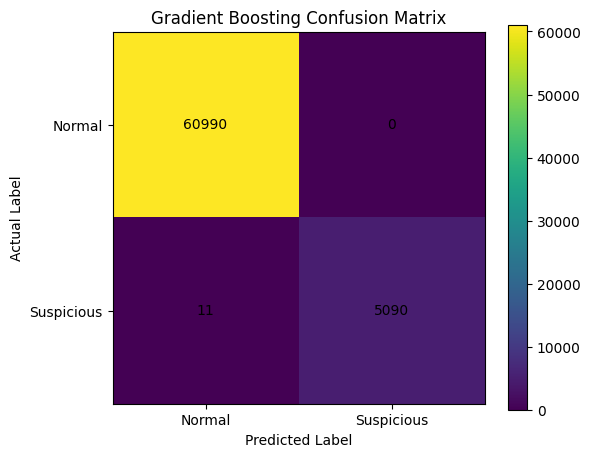

In [94]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0, 1], ["Normal", "Suspicious"])
plt.yticks([0, 1], ["Normal", "Suspicious"])
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [95]:
feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

print("Top Behavioral Features:")
print(feature_importance.to_string(index=False))

Top Behavioral Features:
             feature    importance
      off_hours_http  2.121031e-01
sensitive_file_count  1.836985e-01
  device_disconnects  1.718813e-01
    attachment_count  1.663294e-01
    off_hours_logons  8.926254e-02
     device_connects  8.653902e-02
external_email_count  7.799863e-02
  http_request_count  4.621201e-03
   unique_device_pcs  3.671190e-03
        unique_files  1.999626e-03
     unique_file_pcs  1.057213e-03
 file_activity_count  4.661122e-04
         logon_count  3.684735e-04
          unique_pcs  3.678378e-06
        logoff_count  0.000000e+00
         email_count  0.000000e+00
    unique_email_pcs  0.000000e+00
    unique_http_urls  0.000000e+00
    total_email_size -5.270920e-15


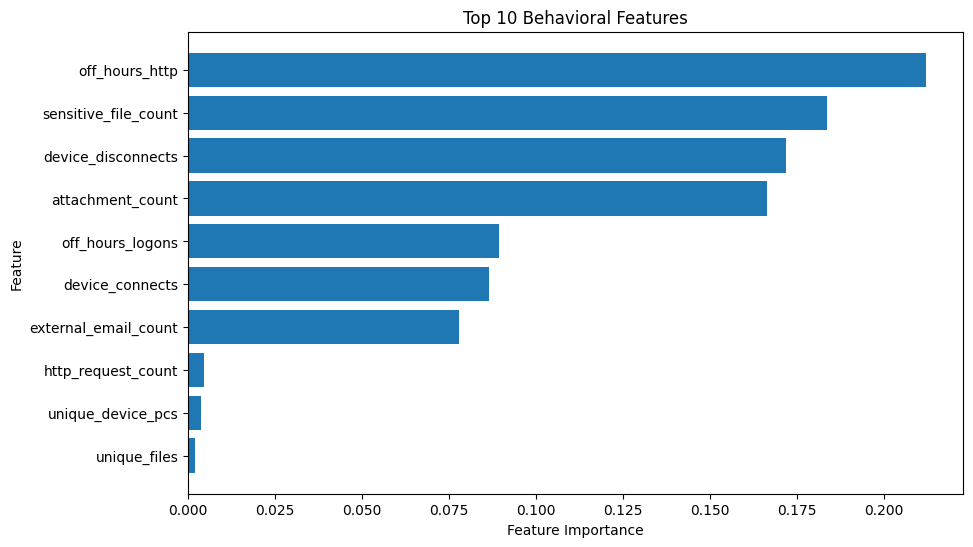

In [96]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(10)

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.title("Top 10 Behavioral Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

In [97]:
X_all_scaled = scaler.transform(
    behavioral_features[feature_columns]
)

behavioral_features["prediction"] = model.predict(
    X_all_scaled
)

behavioral_features["prediction_probability"] = (
    model.predict_proba(X_all_scaled)[:, 1]
)

print("Predictions generated for all behavioral records.")

print(
    behavioral_features[
        [
            "user",
            "day",
            "risk_score",
            "prediction",
            "prediction_probability"
        ]
    ].head(10)
)

Predictions generated for all behavioral records.
      user         day  risk_score  prediction  prediction_probability
0  AAE0190  2010-01-04           0           0                0.000278
1  AAE0190  2010-01-05           0           0                0.000278
2  AAE0190  2010-01-06           1           0                0.014242
3  AAE0190  2010-01-07           0           0                0.000278
4  AAE0190  2010-01-08           0           0                0.000278
5  AAE0190  2010-01-11           0           0                0.000278
6  AAE0190  2010-01-12           0           0                0.000278
7  AAE0190  2010-01-13           0           0                0.000278
8  AAE0190  2010-01-14           0           0                0.000278
9  AAE0190  2010-01-15           0           0                0.000278


In [98]:
behavioral_features["ml_risk_score"] = (
    behavioral_features["prediction_probability"] * 100
)

behavioral_features["behavioral_risk_score"] = (
    behavioral_features["risk_score"] / 6 * 100
)

behavioral_features["final_risk_score"] = (
    0.7 * behavioral_features["ml_risk_score"]
    + 0.3 * behavioral_features["behavioral_risk_score"]
).clip(0, 100)

print("Final risk score created successfully.")

print(
    behavioral_features[
        [
            "user",
            "day",
            "risk_score",
            "prediction_probability",
            "ml_risk_score",
            "behavioral_risk_score",
            "final_risk_score"
        ]
    ].head(10)
)

Final risk score created successfully.
      user         day  risk_score  prediction_probability  ml_risk_score  \
0  AAE0190  2010-01-04           0                0.000278       0.027828   
1  AAE0190  2010-01-05           0                0.000278       0.027828   
2  AAE0190  2010-01-06           1                0.014242       1.424161   
3  AAE0190  2010-01-07           0                0.000278       0.027828   
4  AAE0190  2010-01-08           0                0.000278       0.027828   
5  AAE0190  2010-01-11           0                0.000278       0.027828   
6  AAE0190  2010-01-12           0                0.000278       0.027828   
7  AAE0190  2010-01-13           0                0.000278       0.027828   
8  AAE0190  2010-01-14           0                0.000278       0.027828   
9  AAE0190  2010-01-15           0                0.000278       0.027828   

   behavioral_risk_score  final_risk_score  
0               0.000000          0.019480  
1               0.00000

In [99]:
def get_severity(score):
    if score >= 80:
        return "Critical"
    elif score >= 60:
        return "High"
    elif score >= 40:
        return "Medium"
    else:
        return "Low"


behavioral_features["severity"] = (
    behavioral_features["final_risk_score"]
    .apply(get_severity)
)

print("Severity classification completed successfully.")

print("\nSeverity distribution:")
print(
    behavioral_features["severity"]
    .value_counts()
    .sort_index()
)

Severity classification completed successfully.

Severity distribution:
severity
Critical      5596
High         19496
Low         304945
Medium         415
Name: count, dtype: int64


In [100]:
top_risk = (
    behavioral_features
    .sort_values("final_risk_score", ascending=False)
    .head(20)
)

print("TOP 20 HIGHEST-RISK USER-DAYS")
print("=" * 70)

print(
    top_risk[
        [
            "user",
            "day",
            "final_risk_score",
            "severity",
            "risk_score",
            "prediction_probability"
        ]
    ].to_string(index=False)
)

TOP 20 HIGHEST-RISK USER-DAYS
   user        day  final_risk_score severity  risk_score  prediction_probability
DLM0051 2010-06-02         99.998592 Critical           6                0.999980
DLM0051 2010-05-23         99.998592 Critical           6                0.999980
DLM0051 2010-09-15         99.998592 Critical           6                0.999980
DLM0051 2010-09-05         99.998592 Critical           6                0.999980
THR0873 2010-10-21         94.999994 Critical           5                1.000000
DLM0051 2010-04-30         94.999951 Critical           5                0.999999
DLM0051 2010-06-01         94.999951 Critical           5                0.999999
DLM0051 2010-07-29         94.999951 Critical           5                0.999999
DLM0051 2010-07-22         94.999916 Critical           5                0.999999
GKO0078 2010-10-20         94.999902 Critical           5                0.999999
JCG0316 2010-06-28         94.999902 Critical           5           

In [101]:
behavioral_features.to_csv(
    "/kaggle/working/final_behavioral_risk_results.csv",
    index=False
)

print("✅ Final behavioral risk results saved successfully.")

print(
    behavioral_features.shape
)

✅ Final behavioral risk results saved successfully.
(330452, 29)


In [102]:
import pickle

with open("/kaggle/working/gb.pkl", "wb") as f:
    pickle.dump(model, f)

with open("/kaggle/working/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("/kaggle/working/feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

print("✅ Model files saved successfully.")

✅ Model files saved successfully.


In [103]:
import os

print("KAGGLE OUTPUT FILES")
print("=" * 50)

for filename in [
    "daily_behavioral_features.csv",
    "final_behavioral_risk_results.csv",
    "gb.pkl",
    "scaler.pkl",
    "feature_columns.pkl"
]:
    path = f"/kaggle/working/{filename}"

    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"✅ {filename} — {size_mb:.2f} MB")
    else:
        print(f"❌ {filename} — NOT FOUND")

KAGGLE OUTPUT FILES
✅ daily_behavioral_features.csv — 29.80 MB
✅ final_behavioral_risk_results.csv — 55.03 MB
✅ gb.pkl — 0.13 MB
✅ scaler.pkl — 0.00 MB
✅ feature_columns.pkl — 0.00 MB
